In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [18]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head(1)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0


In [19]:
print("Columns in the dataset: ", df.columns.tolist())

Columns in the dataset:  ['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased']


In [20]:
# Convert gender into numeric
df["Gender"] = df["Gender"].map({'Male': 0, 'Female': 1})
df.head(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,0,19,19000,0
1,15810944,0,35,20000,0
2,15668575,1,26,43000,0
3,15603246,1,27,57000,0
4,15804002,0,19,76000,0


In [21]:
# Features and target
X = df[['Gender', 'EstimatedSalary', 'Age']]
y = df['Purchased']

# Split date
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [22]:
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.fit_transform(X_test)


In [ ]:
# Train the model
# Logistic Regression is used for classification problems.
# Here it predicts whether a user purchases the product or not.
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

# Predict using model
y_pred = classifier.predict(X_test)

In [27]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
comparison

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0
...,...,...
95,0,0
96,1,1
97,0,0
98,1,1


In [40]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Extract values
TN, FP, FN, TP = cm.ravel()

# Metrics
accuracy = accuracy_score(y_test, y_pred)
error = 1 - accuracy
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"True Negative (TN): {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")
print(f"True Positive (TP): {TP}")
print(f"Accuracy: {accuracy}")
print(f"Error: {error}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")


# Confusion matrix shows:
# TN -> Correctly predicted non-purchased users
# TP -> Correctly predicted purchased users
# FP -> Predicted purchased but actually not purchased
# FN -> Predicted not purchased but actually purchased

cm


Confusion Matrix:
 [[61  2]
 [12 25]]
True Negative (TN): 61
False Positive (FP): 2
False Negative (FN): 12
True Positive (TP): 25
Accuracy: 0.86
Error: 0.14
Precision: 0.9259259259259259
Recall: 0.6756756756756757


array([[61,  2],
       [12, 25]])

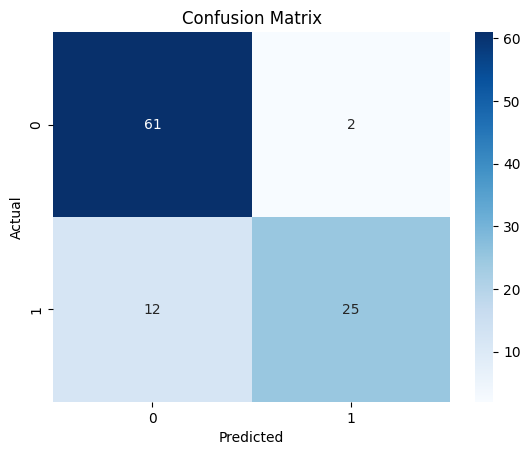

In [ ]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title('Confusion Matrix')
plt.show()

# Predicted = 0 means non purchased and = 1 means purchased
# So when 0, 0 = 61 means -> model predicted wont purchase and actually also ppl wont purchase

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
# macro means calc precision, recall inv for all 3 classes and then do they avg, micro means vice-versa, avg then calc
# avg=None means [a, b, c] -> seperate outputs for all 3 classes
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
error_rate = 1 - accuracy
print(f"Accuracy: {accuracy:.2f}")
print(f"Error Rate: {error_rate:.2f}")
print(f"Precision (Macro): {precision:.2f}")
print(f"Recall (Macro): {recall:.2f}")


Accuracy: 0.86
Error Rate: 0.14
Precision (Macro): 0.88
Recall (Macro): 0.82
